In [ ]:
import requests
from bs4 import BeautifulSoup as BS
import yfinance as yf
import pandas as pd
from dataclasses import dataclass
from typing import Dict, List, Optional, Tuple
import math
import time
import json
import pathlib
import numpy as np
import sys
import pandas as pd
import matplotlib.pyplot as plt

from scipy.signal import find_peaks
from datetime import timedelta

import warnings
warnings.filterwarnings("ignore")

## **Stock Selection**

Before trading, roles of stock selection are set for picking up well performing stock. These roles are as following:



*   Large trading volume
*   Weinstein proxy stage 2 (up trend)
*   Current price is within the 25% 52-week high
*   Price above 200 sma
*   Relative strenght is stronger than the market in the past 6 months
*   Relative strenght of the corresponding sector is stronger than the market in the past 6 months



We can always create a list containing all stock in the market. However, for demo use, I select the stocks in S&P500 for reducing the sample size and confirming the performance of the stocks.

The S&P500 stocks table is created by webscraping from the wikipedia. The stock prices and relvant stock information are collected from yfinance library for 3 years duration.

In [ ]:
PARAMS = {
    "period": "3y",            # history to fetch
    "interval": "1d",
    "market_benchmark": "^GSPC",  # or "SPY"
    "base_window": 50,         # ~10 weeks
    "prior_window": 50,        # for vol contraction comparison
    "min_base_depth": 0.12,    # 12%
    "max_base_depth": 0.33,    # 33%
    "max_sma50_drift": 0.08,   # |(SMA50_now - SMA50_then)/SMA50_then| <= 8%
    "rs_lookback": 126,        # ~6 months
    "rs_slope_window": 100,
    "min_avg_volume": 200_000,
    "min_price": 10.0,
    "within_52w_high_pct": 0.25,   # within 25% of 52w high
    "stage2_slope_window": 20,
    "universe": "SP500",       # SP500 | CSV path | list
    "sector_etf_map": {
        "Communication Services": "XLC",
        "Consumer Discretionary": "XLY",
        "Consumer Staples": "XLP",
        "Energy": "XLE",
        "Financial Services": "XLF",  # Yahoo uses "Financial Services" often
        "Financial": "XLF",
        "Financials": "XLF",
        "Healthcare": "XLV",
        "Health Care": "XLV",
        "Industrials": "XLI",
        "Information Technology": "XLK",
        "Technology": "XLK",
        "Materials": "XLB",
        "Real Estate": "XLRE",
        "Utilities": "XLU",
        # Optional extras:
        "Basic Materials": "XLB"
    }
}

In [ ]:
CACHE_DIR = pathlib.Path("/content/.screen_cache")
CACHE_DIR.mkdir(exist_ok=True)

def load_sp500_symbols():
    sp500_symbols = []
    try:
      import lxml
      PARSER = "lxml"
    except ModuleNotFoundError:
      PARSER = "html.parser"

    with requests.Session() as session:
      headers = {
          "User-Agent": "Mozilla/5.0 (Macintosh; Intel Mac OS X 10_15_7) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/130.0.0.0 Safari/537.3",
          "Accept-Language": "en-GB,en;q=0.9,en-US;q=0.8,pt;q=0.7",
          "Accept-Encoding": "gzip, deflate, br, zstd",
          "Accept": "text/html,application/xhtml+xml,application/xml;q=0.9,image/avif,image/webp,image/apng,*/*;q=0.8,application/signed-exchange;v=b3;q=0.7"
      }
      session.headers.update(headers)

      try:
        with session.get("https://en.wikipedia.org/wiki/List_of_S%26P_500_companies") as response:
          response.raise_for_status()
          soup = BS(response.text, PARSER)
      except Exception as e:
        print(e)

    alldata = soup.find_all('table', {'id': 'constituents'})
    if len(alldata) == 0:
        return sp500_symbols
    for sym_soup in alldata[0].find_all('a', {'class': 'external text'}):
        sym = sym_soup.get_text()
        sp500_symbols.append(sym.replace('.', '-'))
        # print(sym)

    return sp500_symbols

def download_history(tickers, params=PARAMS):
    data = {}
    if not tickers:
        return data
    # yfinance bulk download
    df = yf.download(
        tickers=tickers,
        period=params["period"],
        interval=params["interval"],
        auto_adjust=False,
        group_by="ticker",
        threads=True,
        progress=False
    )
    # Normalize dict of DataFrames
    for t in tickers:
        try:
            sub = df[t].dropna(how="all")
            if not isinstance(sub, pd.DataFrame):
                continue
            sub = sub[["Open", "High", "Low", "Close", "Volume"]].dropna(how="any")
            data[t] = sub
        except Exception:
            # Some tickers may fail or delist
            continue
    return data

def yf_info_cached(ticker: str) -> Dict:
    """Cache Ticker.info to avoid repeated network calls."""
    f = CACHE_DIR / f"info_{ticker}.json"
    if f.exists():
        try:
            return json.loads(f.read_text())
        except Exception:
            pass
    info = {}
    try:
        info = yf.Ticker(ticker).info  # may be slow; caching helps
    except Exception:
        info = {}
    try:
        f.write_text(json.dumps(info))
    except Exception:
        pass
    return info

def sector_for(ticker: str) -> str:
    info = yf_info_cached(ticker)
    sector = info.get("sector") or info.get("industry") or ""
    return sector

def exchange_for(ticker: str) -> str:
    info = yf_info_cached(ticker)
    exch = info.get("exchange") or info.get("fullExchangeName") or info.get("market") or ""
    return exch

In [ ]:
sp500_tickers = load_sp500_symbols()
sp500_tickers[:10]

['MMM', 'AOS', 'ABT', 'ABBV', 'ACN', 'ADBE', 'AMD', 'AES', 'AFL', 'A']

In [ ]:
mkt_hist = yf.download(PARAMS["market_benchmark"], period=PARAMS["period"], interval=PARAMS["interval"], progress=False)
if mkt_hist.empty:
    print("Failed to download market benchmark.", file=sys.stderr)
    sys.exit(1)
mkt_hist.columns = [col[0] for col in mkt_hist.columns]
market_close = mkt_hist["Close"].dropna()

# Preload sector ETFs history (unique values from the mapping)
sector_etfs_list = sorted(set(PARAMS["sector_etf_map"].values()))
sector_hist = download_history(sector_etfs_list, PARAMS)
sector_close_map = {etf: sector_hist.get(etf, pd.DataFrame()).get("Close", pd.Series(dtype=float)) for etf in sector_etfs_list}

# Download equities history
hist_map = download_history(sp500_tickers, PARAMS)

In [ ]:
@dataclass
class ScreenResult:
    ticker: str
    last_close: float
    sma200: float
    sma150_slope: float
    sma200_slope: float
    within_52w_high_pct: float
    base_depth_pct: float
    rs6m_vs_mkt: float
    rs_slope_100d: float
    sector: str
    sector_etf: str
    sector_outperforms: bool
    vol_contract_ok: bool
    avg_vol50: float
    daily_annret: float
    ann_vol: float
    exchange: str
    is_otc: bool
    rs_ok: bool
    base_ok: bool
    stage2_ok: bool
    above_200_ok: bool
    within_high_ok: bool
    passed: bool

def is_otc_exchange(name: Optional[str]) -> bool:
    """Heuristic: treat PNK/OTC/OTC Markets/Other OTC as OTC."""
    if not name:
        return False
    name = name.upper()
    return any(tag in name for tag in ["PNK", "OTC", "OTC MARKETS", "OTHER OTC"])

def rolling_sma(series: pd.Series, window: int) -> pd.Series:
    return series.rolling(window=window, min_periods=window).mean()

def slope(series: pd.Series, window: int) -> float:
    """Return slope of log(series) over `window` via linear fit (per day)."""
    s = series.dropna()
    if len(s) < window:
        return np.nan
    y = np.log(s.tail(window).values)
    x = np.arange(len(y))
    b1, b0 = np.polyfit(x, y, 1)  # slope, intercept
    return float(b1)

def pct_change_over(series: pd.Series, window: int) -> float:
    """Return simple return over window: (last/first - 1)."""
    s = series.dropna()
    if len(s) < window + 1:
        return np.nan
    a, b = s.iloc[-window-1], s.iloc[-1]
    if a == 0 or np.isnan(a) or np.isnan(b):
        return np.nan
    return float(b / a - 1.0)

def evaluate_ticker(t: str,
                    px: pd.DataFrame,
                    mpx: pd.Series,
                    sector_etfs: Dict[str, pd.Series],
                    params=PARAMS) -> Optional[ScreenResult]:
    """
    Evaluate a single ticker using OHLCV history `px` (columns: Open, High, Low, Close, Volume),
    market close series, and sector ETF close series map.
    """
    if px.empty or px["Close"].dropna().empty:
        return None

    close = px["Close"].dropna()
    high = px["High"].reindex(close.index).ffill()
    low  = px["Low"].reindex(close.index).ffill()
    vol  = px["Volume"].reindex(close.index).fillna(0)

    last_close = float(close.iloc[-1])

    ret = close.pct_change().dropna()
    daily_volatility = ret.std()
    annual_volatility = daily_volatility * np.sqrt(len(ret))

    exch = exchange_for(t)
    is_otc = is_otc_exchange(exch)
    if is_otc or last_close < params["min_price"]:
        return None

    avg_vol50 = float(vol.tail(50).mean())

    ret = close.pct_change().dropna()
    cum_ret = (1 + ret).prod() - 1
    cum_ret = cum_ret
    daily_annret = ((1 + cum_ret)**(252 / len(ret))) - 1

    if avg_vol50 < params["min_avg_volume"]:
        return None

    # Moving averages
    sma50 = rolling_sma(close, 50)
    sma150 = rolling_sma(close, 150)
    sma200 = rolling_sma(close, 200)

    # Stage 2 (Weinstein proxy)
    sma150_slope = slope(sma150, params["stage2_slope_window"])
    sma200_slope = slope(sma200, params["stage2_slope_window"])
    stage2_ok = (
        last_close > (sma150.iloc[-1] if not math.isnan(sma150.iloc[-1]) else np.inf) and
        last_close > (sma200.iloc[-1] if not math.isnan(sma200.iloc[-1]) else np.inf) and
        (sma150_slope if not np.isnan(sma150_slope) else -1) > 0 and
        (sma200_slope if not np.isnan(sma200_slope) else -1) > 0
    )

    # Within 25% of 52-week high
    high_52w = float(close.rolling(252, min_periods=252).max().iloc[-1]) if len(close) >= 252 else np.nan
    if np.isnan(high_52w) or high_52w <= 0:
        return None
    within_high_pct = 1.0 - (last_close / high_52w)  # 0.0 means at high; 0.25 means 25% below high
    within_high_ok = within_high_pct <= params["within_52w_high_pct"]

    # Price above 200-DMA
    sma200_now = float(sma200.iloc[-1]) if not np.isnan(sma200.iloc[-1]) else np.nan
    above_200_ok = not np.isnan(sma200_now) and last_close > sma200_now

    # Properly formed base (heuristic)
    B = params["base_window"]
    P = params["prior_window"]

    seg_recent = close.tail(B)
    seg_prior  = close.tail(B + P).head(P)

    base_high = float(seg_recent.max())
    base_low  = float(seg_recent.min())
    base_depth = 1.0 - (base_low / base_high) if base_high > 0 else np.nan

    sma50_recent = float(sma50.iloc[-1]) if not np.isnan(sma50.iloc[-1]) else np.nan
    sma50_past   = float(sma50.iloc[-B]) if len(sma50.dropna()) >= B else np.nan
    sma50_drift = abs((sma50_recent - sma50_past) / sma50_past) if (sma50_past not in [0, np.nan]) else np.nan

    vol_recent = seg_recent.pct_change().std()
    vol_prior  = seg_prior.pct_change().std()
    vol_contract_ok = (not np.isnan(vol_recent) and not np.isnan(vol_prior) and vol_prior > 0 and (vol_recent <= 0.9 * vol_prior))

    base_ok = (
        (params["min_base_depth"] <= base_depth <= params["max_base_depth"]) and
        (not np.isnan(sma50_drift) and sma50_drift <= params["max_sma50_drift"]) and
        vol_contract_ok
    )

    # Relative strength vs market (6M + RS slope)
    market = mpx.reindex(close.index).dropna()
    if len(market) < (params["rs_lookback"] + 5):
        return None

    rs6m_stock = pct_change_over(close, params["rs_lookback"])
    rs6m_mkt   = pct_change_over(market, params["rs_lookback"])
    rs6m_vs_mkt = (rs6m_stock - rs6m_mkt) if (not np.isnan(rs6m_stock) and not np.isnan(rs6m_mkt)) else np.nan

    ratio = (close / market).dropna()
    rs_slope_100d = slope(ratio, params["rs_slope_window"])

    rs_ok = (not np.isnan(rs6m_vs_mkt) and rs6m_vs_mkt > 0) and (not np.isnan(rs_slope_100d) and rs_slope_100d > 0)

    # Sector RS vs market
    sect = sector_for(t)
    etf = None
    for key, val in params["sector_etf_map"].items():
        if key.lower() in sect.lower():
            etf = val
            break
    sector_outperforms = False
    sector_name = sect
    sector_etf_ticker = etf or ""

    if etf and etf in sector_etfs:
        etf_close = sector_etfs[etf].reindex(close.index).dropna()
        if len(etf_close) >= (params["rs_lookback"] + 5):
            sec6m = pct_change_over(etf_close, params["rs_lookback"])
            mkt6m = pct_change_over(market, params["rs_lookback"])
            if not np.isnan(sec6m) and not np.isnan(mkt6m):
                sector_outperforms = (sec6m >= mkt6m)
    else:
        # If sector missing, be conservative: require False (fail) to avoid accidental pass
        sector_outperforms = False

    passed = all([
        stage2_ok,
        # base_ok,
        rs_ok,
        sector_outperforms,
        above_200_ok,
        within_high_ok
    ])

    return ScreenResult(
        ticker=t,
        last_close=last_close,
        sma200=sma200_now if not np.isnan(sma200_now) else np.nan,
        sma150_slope=sma150_slope if not np.isnan(sma150_slope) else np.nan,
        sma200_slope=sma200_slope if not np.isnan(sma200_slope) else np.nan,
        within_52w_high_pct=within_high_pct,
        base_depth_pct=base_depth,
        base_ok=base_ok,
        stage2_ok=stage2_ok,
        rs6m_vs_mkt=rs6m_vs_mkt if not np.isnan(rs6m_vs_mkt) else np.nan,
        rs_slope_100d=rs_slope_100d if not np.isnan(rs_slope_100d) else np.nan,
        rs_ok=rs_ok,
        sector=sector_name,
        sector_etf=sector_etf_ticker,
        vol_contract_ok=vol_contract_ok,
        sector_outperforms=sector_outperforms,
        avg_vol50=avg_vol50,
        daily_annret=daily_annret,
        ann_vol=annual_volatility,
        exchange=exch,
        is_otc=is_otc,
        above_200_ok=above_200_ok,
        within_high_ok=within_high_ok,
        passed=passed
    )

In [ ]:
rows: List[ScreenResult] = []
n = len(hist_map)
for i, (t, dfpx) in enumerate(hist_map.items(), 1):
    if i % 50 == 0:
        print(f"Processed {i}/{n}...")
    try:
        res = evaluate_ticker(t, dfpx, market_close, sector_close_map, PARAMS)
        if res:
            rows.append(res)
    except Exception:
        continue

Processed 50/503...
Processed 100/503...
Processed 150/503...
Processed 200/503...
Processed 250/503...
Processed 300/503...
Processed 350/503...
Processed 400/503...
Processed 450/503...
Processed 500/503...


In [ ]:
df_out = pd.DataFrame([r.__dict__ for r in rows])
df_out.to_csv('out.csv')

# Hard filters that depend on metadata (some already applied)
df_out = df_out.loc[
    (df_out["avg_vol50"] >= PARAMS["min_avg_volume"]) &
    (df_out["last_close"] >= PARAMS["min_price"]) &
    (~df_out["is_otc"])
].copy()

df_pass = df_out.loc[df_out["passed"]].copy()

# Sort by strongest RS then proximity to high
df_pass["within_high_rank"] = df_pass["within_52w_high_pct"].rank(ascending=True)
df_pass["dailyret_rank"] = df_pass["daily_annret"].rank(ascending=True)
df_pass["rs_rank"] = (-df_pass["rs6m_vs_mkt"]).rank(ascending=True)
df_pass = df_pass.sort_values(["dailyret_rank", "rs_rank", "within_high_rank"])

In [ ]:
len(df_pass)

37

From the selection, there are 37 stocks are selected from the S&P500. One way to perform portfolio management is to pick up individal stock from these stocks and perfrom simple trend using the index. Therefore, the stocks are ranked with their **daily return**. The top 10 of daily return ticker are the following:


In [ ]:
df_pass[["ticker", "daily_annret", "within_52w_high_pct", "dailyret_rank", "rs_rank"]].tail(10)

,ticker,daily_annret,within_52w_high_pct,dailyret_rank,rs_rank
140,DELL,0.558245,0.059727,28.0,16.0
350,ORCL,0.637418,0.128499,29.0,7.0
404,STX,0.647310,0.015769,30.0,2.0
484,WDC,0.687392,0.000000,31.0,1.0
43,ANET,0.693625,0.049268,32.0,10.0
307,META,0.722335,0.100557,33.0,33.0
70,AVGO,0.924257,0.084422,34.0,6.0
342,NVDA,1.435809,0.006724,35.0,14.0
354,PLTR,1.749633,0.074739,36.0,9.0
39,APP,2.199215,0.049795,37.0,3.0


## **Trading with technical indicator**

In [ ]:
!pip install backtesting ta

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 192.1/192.1 kB 3.9 MB/s eta 0:00:00
  Created wheel for ta: filename=ta-0.11.0-py3-none-any.whl size=29412 sha256=22bc061d029c895deb54410bd159c6ce8c657fa5109e5e36178e8e5248286e39
  Stored in directory: /root/.cache/pip/wheels/5c/a1/5f/c6b85a7d9452057be4ce68a8e45d77ba34234a6d46581777c6
Successfully built ta


To trade with the technical indicators, some popular indicators are chosen.


*   SMA
*   EMA
*   MACD

The trading stradegies are defined as following:


1.   10-day sma cross over 20-day sma (golden cross)
2.   10-day sma cross over closing price
3.   10-day ema cross over closing price
4.   MACD signal





In [ ]:
# sel_tickers = df_pass['ticker'].iloc[-10:].tolist()
sel_tickers = ['DELL', 'ORCL', 'STX', 'WDC', 'ANET', 'META', 'AVGO', 'NVDA', 'PLTR', 'APP', 'SPY']
sel_tickers

['DELL',
 'ORCL',
 'STX',
 'WDC',
 'ANET',
 'META',
 'AVGO',
 'NVDA',
 'PLTR',
 'APP',
 'SPY']

In [ ]:
from backtesting import Backtest, Strategy
from backtesting.lib import crossover
import pandas as pd

from backtesting.test import SMA
import yfinance as yf

def EMA(series, n):
    s = pd.Series(series)
    return s.ewm(span=n, adjust=False).mean().to_numpy()

def MACD_line(series, fast=12, slow=26):
    s = pd.Series(series)
    ema_fast = s.ewm(span=fast, adjust=False).mean()
    ema_slow = s.ewm(span=slow, adjust=False).mean()
    return (ema_fast - ema_slow).to_numpy()

def MACD_signal(series, fast=12, slow=26, signal=9):
    s = pd.Series(series)
    ema_fast = s.ewm(span=fast, adjust=False).mean()
    ema_slow = s.ewm(span=slow, adjust=False).mean()
    macd = ema_fast - ema_slow
    sig = macd.ewm(span=signal, adjust=False).mean()
    return sig.to_numpy()

In [ ]:
def SmaCrossBackTesting(symbols, start, end):
    class SmaCross(Strategy):
        n1 = 10
        n2 = 20

        def init(self):
            close = self.data.Close
            self.sma1 = self.I(SMA, close, self.n1)
            self.sma2 = self.I(SMA, close, self.n2)

        def next(self):
            if crossover(self.sma1, self.sma2):
                self.buy()

            elif crossover(self.sma2, self.sma1):
                self.sell()

    px =yf.download(symbols,start=start, end=end, auto_adjust = True)

    # Check if it's a MultiIndex and flatten it
    if isinstance(px.columns, pd.MultiIndex):
        px.columns = px.columns.droplevel(0)  # Remove first level (ticker symbol)

    # Rename columns if necessary
    px.columns = ["Open", "High", "Low", "Close", "Volume"]

    # Print the cleaned dataset to verify
    # print(px.head())

    bt = Backtest(px, SmaCross,
                  cash=10000, commission=.002,
                  exclusive_orders=True)

    output = bt.run()
    # plots = bt.plot()
    return output

def SmaCloseCrossBackTesting(symbols, start, end):
    class SmaCloseCross(Strategy):
        nday = 10

        def init(self):
            close = self.data.Close
            self.sma = self.I(SMA, close, self.nday)

        def next(self):
            if crossover(self.data.Close, self.sma):
                self.buy()

            elif crossover(self.sma, self.data.Close):
                self.sell()

    px =yf.download(symbols,start=start, end=end, auto_adjust = True)

    # Check if it's a MultiIndex and flatten it
    if isinstance(px.columns, pd.MultiIndex):
        px.columns = px.columns.droplevel(0)  # Remove first level (ticker symbol)

    # Rename columns if necessary
    px.columns = ["Open", "High", "Low", "Close", "Volume"]

    # Print the cleaned dataset to verify
    # print(px.head())

    bt = Backtest(px, SmaCloseCross,
                  cash=10000, commission=.002,
                  exclusive_orders=True)

    output = bt.run()
    # plots = bt.plot()
    return output

def EmaCrossBackTesting(symbols, start, end):
    class EmaCross(Strategy):
        n1 = 10

        def init(self):
            close = self.data.Close
            self.ema = self.I(EMA, close, self.n1)

        def next(self):
            if crossover(self.data.Close, self.ema):
                self.buy()

            elif crossover(self.ema, self.data.Close):
                self.sell()

    px =yf.download(symbols,start=start, end=end, auto_adjust = True)

    # Check if it's a MultiIndex and flatten it
    if isinstance(px.columns, pd.MultiIndex):
        px.columns = px.columns.droplevel(0)  # Remove first level (ticker symbol)

    # Rename columns if necessary
    px.columns = ["Open", "High", "Low", "Close", "Volume"]

    # Print the cleaned dataset to verify
    # print(px.head())

    bt = Backtest(px, EmaCross,
                  cash=10000, commission=.002,
                  exclusive_orders=True)

    output = bt.run()
    # plots = bt.plot()
    return output

def MACDSingalBackTesting(symbols, start, end):
    class MACDSingal(Strategy):
        macd_fast = 12
        macd_slow = 26
        macd_signal_n = 9

        def init(self):
            close = self.data.Close

            self.macd = self.I(MACD_line, close, self.macd_fast, self.macd_slow)
            self.macd_sig = self.I(MACD_signal, close, self.macd_fast, self.macd_slow, self.macd_signal_n)

        def next(self):
            if self.macd[-1] > self.macd_sig[-1]:
                self.buy()
            elif self.macd[-1] < self.macd_sig[-1]:
                self.sell()

    px =yf.download(symbols,start=start, end=end, auto_adjust = True)

    # Check if it's a MultiIndex and flatten it
    if isinstance(px.columns, pd.MultiIndex):
        px.columns = px.columns.droplevel(0)  # Remove first level (ticker symbol)

    # Rename columns if necessary
    px.columns = ["Open", "High", "Low", "Close", "Volume"]

    # Print the cleaned dataset to verify
    # print(px.head())

    bt = Backtest(px, MACDSingal,
                  cash=10000, commission=.002,
                  exclusive_orders=True)

    output = bt.run()
    # plots = bt.plot()
    return output

In [ ]:
from ta.trend import MACD, SMAIndicator, EMAIndicator
import yfinance as yf
import pandas as pd
from datetime import datetime
import warnings
warnings.filterwarnings("ignore")


In [ ]:
def trade_with_indicator(ticker, start_day):
    df = yf.download(ticker,start="2022-01-01", end="2025-08-31", auto_adjust = True)
    df.columns = ["Open", "High", "Low", "Close", "Volume"]

    macd = MACD(df['Close'], window_slow=26, window_fast=12, window_sign=9)
    df['MACD'] = macd.macd()
    df['MACD_signal'] = macd.macd_signal()

    sma10 =  SMAIndicator(df["Close"], window=10)
    sma20 =  SMAIndicator(df["Close"], window=20)

    df['sma10'] = sma10.sma_indicator()
    df['sma20'] = sma20.sma_indicator()

    ema10 =  EMAIndicator(df["Close"], window=10)
    df['ema10'] = ema10.ema_indicator()

    entry_price = {'sma10x20': None,'sma10': None,'ema10': None,'MACD': None}
    profit = {'sma10x20': 0,'sma10': 0,'ema10': 0,'MACD': 0}
    logs = {'sma10x20': [],'sma10': [],'ema10': [],'MACD': []}

    st_day = datetime.strptime(start_day, '%Y-%m-%d')
    period_of_interest = df.index[df.index >= st_day]
    for iday in range(1, len(period_of_interest), 1):
        cur_day = period_of_interest[iday]

        cur_price = df['Close'].loc[cur_day]
        cur_sma10 = df['sma10'].loc[cur_day]
        cur_sma20 = df['sma20'].loc[cur_day]
        cur_ema10 = df['ema10'].loc[cur_day]
        cur_macd = df['MACD'].loc[cur_day]
        cur_macd_signal = df['MACD_signal'].loc[cur_day]

        if entry_price['sma10x20'] is not None:
            if cur_sma20 > cur_sma10:
                profit['sma10x20'] += cur_price - entry_price['sma10x20']
                logs['sma10x20'].append((cur_price,entry_price['sma10x20']))
                entry_price['sma10x20'] = None
        else:
            if cur_sma20 < cur_sma10 or len(logs['sma10x20']) == 0:
                entry_price['sma10x20'] = cur_price

        if entry_price['sma10'] is not None:
            if cur_sma10 > cur_price:
                profit['sma10'] += cur_price - entry_price['sma10']
                logs['sma10'].append((cur_price,entry_price['sma10']))
                entry_price['sma10'] = None
        else:
            if cur_sma10 < cur_price or len(logs['sma10']) == 0:
                entry_price['sma10'] = cur_price

        if entry_price['ema10'] is not None:
            if cur_ema10 > cur_price:
                profit['ema10'] += cur_price - entry_price['ema10']
                logs['ema10'].append((cur_price,entry_price['ema10']))
                entry_price['ema10'] = None
        else:
            if cur_ema10 < cur_price or len(logs['ema10']) == 0:
                entry_price['ema10'] = cur_price

        if entry_price['MACD'] is not None:
            if cur_macd > cur_macd_signal:
                profit['MACD'] += cur_price - entry_price['MACD']
                logs['MACD'].append((cur_price,entry_price['MACD']))
                entry_price['MACD'] = None
        else:
            if cur_macd_signal < cur_macd or len(logs['MACD']) == 0:
                entry_price['MACD'] = cur_price

    last_close_price = df['Close'].iloc[-1]
    if entry_price['sma10x20'] is not None:
        profit['sma10x20'] += last_close_price - entry_price['sma10x20']
        logs['sma10x20'].append((cur_price,entry_price['sma10x20']))
    if entry_price['sma10'] is not None:
        profit['sma10'] += last_close_price - entry_price['sma10']
        logs['sma10'].append((cur_price,entry_price['sma10']))
    if entry_price['ema10'] is not None:
        profit['ema10'] += last_close_price - entry_price['ema10']
        logs['ema10'].append((cur_price,entry_price['ema10']))
    if entry_price['MACD'] is not None:
        profit['MACD'] += last_close_price - entry_price['MACD']
        logs['MACD'].append((last_close_price,entry_price['MACD']))

    profit['buy&hold'] = df['Close'].loc[period_of_interest[-1]] - df['Close'].loc[period_of_interest[0]]

    return profit

In [ ]:
trade_results_01 = {}
st_time = "2023-01-01"
end_time = "2025-08-31"
for ticker in sel_tickers:
    output_sma10x20 = SmaCrossBackTesting(ticker, st_time, end_time)
    output_sma10xc = SmaCloseCrossBackTesting(ticker, st_time, end_time)
    output_ema10xc = EmaCrossBackTesting(ticker, st_time, end_time)
    output_macd = MACDSingalBackTesting(ticker, st_time, end_time)

    trade_results_01[ticker] = {
        'sma10x20': output_sma10x20['Return [%]'],
        'sma10xc': output_sma10xc['Return [%]'],
        'ema10xc': output_ema10xc['Return [%]'],
        'macd': output_macd['Return [%]'],
        'buy&hold': output_sma10x20['Buy & Hold Return [%]']
    }


[*********************100%***********************]  1 of 1 completed


Backtest.run:   0%|          | 0/647 [00:00<?, ?bar/s]

[*********************100%***********************]  1 of 1 completed


Backtest.run:   0%|          | 0/657 [00:00<?, ?bar/s]

[*********************100%***********************]  1 of 1 completed


...

Backtest.run:   0%|          | 0/657 [00:00<?, ?bar/s]

[*********************100%***********************]  1 of 1 completed


Backtest.run:   0%|          | 0/666 [00:00<?, ?bar/s]

[*********************100%***********************]  1 of 1 completed


Backtest.run:   0%|          | 0/666 [00:00<?, ?bar/s]

In [ ]:
df_trade_results_01 = pd.DataFrame(trade_results_01)
df_trade_results_01

,DELL,ORCL,STX,WDC,ANET,META,AVGO,NVDA,PLTR,APP,SPY
sma10x20,-67.514556,18.437582,-51.636760,-70.597772,-42.963295,31.923359,-64.793897,15.191686,-53.623073,300.732072,-15.682071
sma10xc,-49.964042,39.638444,58.482221,80.036401,-43.870862,12.988527,-38.870953,-41.295364,-86.178691,-12.411352,-26.196343
ema10xc,-54.330400,140.301514,138.164221,133.393015,-56.706434,-10.612262,-54.136688,-34.603585,-79.889362,-24.610531,-31.282665
macd,-97.456277,-79.835871,-93.876279,-94.133523,-95.930631,-92.673152,-96.058629,-93.959809,-98.431961,-95.834995,-92.869167
buy&hold,226.707264,179.679929,183.228034,151.671758,338.189160,406.501344,449.660617,829.933838,2018.488515,3808.292632,66.958069


In [ ]:
trade_results_01 = {}
st_time = "2023-01-01"
for ticker in sel_tickers:
    trade_results_01[ticker] = trade_with_indicator(ticker, st_time)


[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


In [ ]:
df_trade_results_01 = pd.DataFrame(trade_results_01)
df_trade_results_01

,DELL,ORCL,STX,WDC,ANET,META,AVGO,NVDA,PLTR,APP,SPY
sma10x20,13.236633,101.631893,72.742319,19.705907,65.204994,472.009437,150.025096,123.412336,63.180011,317.505004,166.883368
sma10,34.471521,137.083406,95.674501,49.930827,50.432484,299.835712,151.231199,123.595347,124.734992,453.169973,171.609939
ema10,33.229685,133.373807,95.506526,52.431858,58.488720,254.990801,140.086910,81.806616,118.905002,399.816975,169.928434
MACD,145.023782,135.045704,63.772178,45.166981,94.387537,291.872346,158.262162,36.976851,100.326984,43.105042,143.348905
buy&hold,85.796606,157.734303,123.072360,57.413509,104.782494,622.709872,252.361159,163.262979,150.399996,469.910001,275.106543


In [ ]:
trade_results_02 = {}
st_time = "2025-02-01"
end_time = "2025-08-31"
for ticker in sel_tickers:
    output_sma10x20 = SmaCrossBackTesting(ticker, st_time, end_time)
    output_sma10xc = SmaCloseCrossBackTesting(ticker, st_time, end_time)
    output_ema10xc = EmaCrossBackTesting(ticker, st_time, end_time)
    output_macd = MACDSingalBackTesting(ticker, st_time, end_time)

    trade_results_02[ticker] = {
        'sma10x20': output_sma10x20['Return [%]'],
        'sma10xc': output_sma10xc['Return [%]'],
        'ema10xc': output_ema10xc['Return [%]'],
        'macd': output_macd['Return [%]'],
        'buy&hold': output_sma10x20['Buy & Hold Return [%]']
    }


[*********************100%***********************]  1 of 1 completed


Backtest.run:   0%|          | 0/125 [00:00<?, ?bar/s]

[*********************100%***********************]  1 of 1 completed


Backtest.run:   0%|          | 0/135 [00:00<?, ?bar/s]

[*********************100%***********************]  1 of 1 completed


...

Backtest.run:   0%|          | 0/135 [00:00<?, ?bar/s]

[*********************100%***********************]  1 of 1 completed


Backtest.run:   0%|          | 0/144 [00:00<?, ?bar/s]

[*********************100%***********************]  1 of 1 completed


Backtest.run:   0%|          | 0/144 [00:00<?, ?bar/s]

In [ ]:
df_trade_results_02 = pd.DataFrame(trade_results_02)
df_trade_results_02

,DELL,ORCL,STX,WDC,ANET,META,AVGO,NVDA,PLTR,APP,SPY
sma10x20,-44.278732,80.712732,123.674519,36.426706,72.773030,1.860207,73.909738,53.338099,-8.860649,21.274964,-6.247364
sma10xc,13.156465,42.923688,127.222196,138.857465,28.544816,31.646479,2.121446,3.876382,-0.481762,-0.953577,0.777181
ema10xc,30.607559,88.973939,160.335134,188.538974,10.491770,24.045245,2.547533,-13.876624,4.552028,14.093606,1.314251
macd,-51.565557,-1.844676,-9.454488,-16.946775,-34.396613,-43.817975,-57.685229,-45.809212,-62.194212,-21.432010,-51.006710
buy&hold,20.933671,43.138822,69.393098,64.961626,45.600081,10.811821,51.305784,44.230221,77.278363,37.254458,9.251839


In [ ]:
trade_results_02 = {}
st_time = "2024-04-01"
for ticker in sel_tickers:
    trade_results_02[ticker] = trade_with_indicator(ticker, st_time)

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


In [ ]:
df_trade_results_02 = pd.DataFrame(trade_results_02)
df_trade_results_02

,DELL,ORCL,STX,WDC,ANET,META,AVGO,NVDA,PLTR,APP,SPY
sma10x20,-33.142413,98.619010,74.276757,19.148273,44.129990,188.363240,134.882320,64.995569,54.370012,283.440002,66.520570
sma10,-17.930898,109.506323,70.787948,30.692055,41.969975,88.546172,104.139197,68.933381,116.309990,413.779976,63.507620
ema10,-11.894719,113.564863,67.805167,33.419165,46.302460,47.726753,106.545897,30.294489,113.220001,368.104973,57.920878
MACD,90.886066,1.567817,22.524021,22.898865,-14.892509,150.131755,55.052445,103.486400,49.122023,16.444038,63.557267
buy&hold,12.641026,113.920647,81.782760,29.538769,62.439995,260.048639,176.049009,87.841973,133.999996,411.680000,131.383629


For a two year period, no strageries can win the return from buy&hold. However, For a shorter period, some strageries have a better performance than buy&hold. But, to reduce the risk, buy&hold would be the most suitable way to make profit due to the future uncertainty.

## **Protfolio Omptization**

The second way to trade with the stocks is to perform the protfolio omptization to maximum the return with optimzed risk.

The top 10 stock and last 10 stocks from the 37 stocks are selected to perform the optimization

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import os
import pandas as pd
import yfinance as yf
from scipy.optimize import minimize
import plotly.graph_objects as go
import plotly.io as pio

In [ ]:
df_pass_sortvol = df_pass.sort_values(["ann_vol"]).copy()

NameError: name 'df_pass' is not defined

In [ ]:
df_pass_sortvol.head(10)

In [ ]:
df_pass_sortvol.tail(10)

,ticker,last_close,sma200,sma150_slope,sma200_slope,within_52w_high_pct,base_depth_pct,rs6m_vs_mkt,rs_slope_100d,sector,...,is_otc,rs_ok,base_ok,stage2_ok,above_200_ok,within_high_ok,passed,within_high_rank,dailyret_rank,rs_rank
311,MU,187.830002,106.608450,0.004119,0.002979,0.000000,0.441623,1.282168,0.003293,Technology,...,False,True,False,True,True,True,True,3.0,26.0,4.0
6,AMD,164.669998,128.017750,0.002565,0.000885,0.107093,0.180458,0.511077,0.003046,Technology,...,False,True,False,True,True,True,True,35.0,19.0,19.0
246,INTC,36.830002,22.393100,0.002043,0.001615,0.012600,0.482306,0.397531,0.002543,Technology,...,False,True,False,True,True,True,True,12.0,2.0,23.0
342,NVDA,187.619995,143.058800,0.002142,0.001362,0.006724,0.115782,0.598559,0.002090,Technology,...,False,True,False,True,True,True,True,9.0,35.0,14.0
319,MPWR,918.830017,693.351102,0.002027,0.002275,0.025848,0.235645,0.598058,0.001834,Technology,...,False,True,False,True,True,True,True,16.0,16.0,15.0
193,FSLR,230.130005,167.545200,0.002266,0.000547,0.021223,0.247275,0.444809,0.002183,Technology,...,False,True,False,True,True,True,True,14.0,5.0,21.0
477,WBD,18.990000,11.266700,0.005053,0.003807,0.041877,0.456105,0.828677,0.005287,Communication Services,...,False,True,False,True,True,True,True,25.0,4.0,8.0
356,PSKY,19.090000,12.516900,0.003938,0.003122,0.032438,0.487076,0.418425,0.003402,Communication Services,...,False,True,False,True,True,True,True,20.0,1.0,22.0
354,PLTR,173.070007,121.557400,0.003555,0.004656,0.074739,0.181449,0.825749,0.002582,Technology,...,False,True,False,True,True,True,True,32.0,36.0,9.0
39,APP,682.760010,380.217051,0.004003,0.004042,0.049795,0.496716,1.361686,0.004970,Communication Services,...,False,True,False,True,True,True,True,27.0,37.0,3.0


In [ ]:
# portop_tickers = df_pass_sortvol['ticker'].iloc[-10:].tolist() + df_pass_sortvol['ticker'].iloc[:10].tolist()
portop_tickers = ['MU', 'AMD', 'INTC', 'NVDA', 'MPWR', 'FSLR',
 'WBD', 'PSKY', 'PLTR', 'APP', 'TDY', 'EA', 'TEL', 'LDOS',
 'PTC', 'FFIV', 'AAPL', 'APH', 'GLW', 'GRMN']

In [ ]:
start_date = '2020-10-31'
end_date = '2025-8-31'

prices_combined_df = pd.DataFrame()
for ticker in portop_tickers:
    data = yf.download(ticker, start=start_date, end=end_date, progress=False, auto_adjust = False)

    data.columns = data.columns.get_level_values(1)

    data.reset_index(inplace=True)
    data['Ticker Symbol'] = ticker

    data.columns = ['Date', 'Adj Close', 'Close', 'High', 'Low', 'Open', 'Volume', 'Ticker Symbol']

    prices_combined_df = pd.concat([prices_combined_df, data], ignore_index=True)

prices_combined_df = prices_combined_df[[
    'Date', 'Ticker Symbol',
    'Open', 'High', 'Low', 'Close', 'Adj Close', 'Volume'
]]
prices_combined_df['Date'] = pd.to_datetime(prices_combined_df['Date']).dt.strftime('%d/%m/%Y')

combined_df = prices_combined_df.copy()
combined_df.sort_values(by=['Ticker Symbol', 'Date'], inplace=True)
combined_df['Date'] = pd.to_datetime(combined_df['Date'], errors='coerce')

# Resample data by month-end, preserving the Ticker Symbol (JP) column
monthly_df = (
    combined_df.set_index('Date')
    .groupby('Ticker Symbol', group_keys=False)
    .resample('ME')  # Month-end frequency
    .last()
    .reset_index()
)

monthly_price = monthly_df.pivot(index='Date', columns='Ticker Symbol', values='Adj Close')
monthly_returns = monthly_price.pct_change().dropna()

In [ ]:
def annualize_rets(ret, periods_per_year=12):
    """Calculates annualized returns."""
    compounded_growth = (1 + ret).prod()
    n_periods = ret.shape[0]
    return compounded_growth ** (periods_per_year / n_periods) - 1


def portfolio_return(weights, returns):
    """Calculates portfolio return given weights."""
    return weights.T @ returns


def portfolio_vol(weights, covmat):
    """Calculates portfolio volatility given weights and covariance matrix."""
    vol = weights.T @ covmat @ weights
    return vol ** 0.5


def msr(riskfree_rate, ret, covmat, bound=(0.008, 0.1)):
    """Finds the portfolio weights that maximize the Sharpe Ratio."""
    n = ret.shape[0]
    init_guess = np.repeat(1 / n, n)
    bounds = (bound,) * n
    weights_sum_to_1 = {'type': 'eq', 'fun': lambda weights: np.sum(weights) - 1}

    def neg_sharpe(weights, riskfree_rate, er, cov):
        r = portfolio_return(weights, er)
        vol = portfolio_vol(weights, cov)
        return -(r - riskfree_rate) / vol

    weights = minimize(neg_sharpe, init_guess, args=(riskfree_rate, ret, covmat),
                       method='SLSQP', options={'disp': False},
                       constraints=(weights_sum_to_1,), bounds=bounds)
    return weights.x


def minimize_vol(target_return, ret, cov, bound=(0.008, 0.1)):
    """Finds the weights that minimize volatility for a target return."""
    n = ret.shape[0]
    init_guess = np.repeat(1 / n, n)
    bounds = (bound,) * n
    weights_sum_to_1 = {'type': 'eq', 'fun': lambda weights: np.sum(weights) - 1}
    return_is_target = {'type': 'eq', 'args': (ret,),
                        'fun': lambda weights, ret: target_return - portfolio_return(weights, ret)}

    weights = minimize(portfolio_vol, init_guess, args=(cov,), method='SLSQP',
                       options={'disp': False}, constraints=(weights_sum_to_1, return_is_target),
                       bounds=bounds)
    return weights.x

def risk_parity_objective(weights, cov_matrix):
    risk_contribs = risk_contribution(weights, cov_matrix)
    mean_risk_contrib = np.mean(risk_contribs)
    sum_sq_diff = np.sum(np.square(risk_contribs - mean_risk_contrib))
    return sum_sq_diff

def risk_contribution(weights, cov_matrix):
    portfolio_vol = np.sqrt(np.dot(weights.T, np.dot(cov_matrix, weights)))
    marginal_contrib = np.dot(cov_matrix, weights)
    risk_contrib = np.multiply(marginal_contrib, weights) / portfolio_vol
    return risk_contrib

def min_risk_parity(risk_free_rate, returns, cov_matrix, bound):

    n_assets = returns.shape[0]
    init_weights = np.ones(n_assets) / n_assets

    # Constraints
    bounds = tuple(bound for _ in range(n_assets))
    constraints = {'type': 'eq', 'fun': lambda x: np.sum(x) - 1}

    # Optimize
    result = minimize(risk_parity_objective, init_weights,
                    args=(cov_matrix,),
                    method='SLSQP',
                    bounds=bounds,
                    constraints=constraints,
                    options={'ftol': 1e-12, 'maxiter': 1000})

    return result.x

def min_volatility(risk_free_rate, returns, cov_matrix, bound):

    n_assets = returns.shape[0]
    init_weights = np.ones(n_assets) / n_assets

    # Constraints
    bounds = tuple(bound for _ in range(n_assets)) # each asset
    constraints = {'type': 'eq', 'fun': lambda x: np.sum(x) - 1}

    weights = minimize(portfolio_vol, init_weights,
                        args=(cov_matrix,), method='SLSQP',
                        options={'disp': False},
                        constraints=constraints,
                        bounds=bounds)

    return weights.x

def maximize_return(target_vol, ret, cov, bound=(0.008, 0.1)):
    """Finds the weights that minimize volatility for a target return."""
    n = ret.shape[0]
    init_guess = np.repeat(1 / n, n)
    bounds = (bound,) * n
    weights_sum_to_1 = {'type': 'eq', 'fun': lambda weights: np.sum(weights) - 1}
    volatility_is_target = {'type': 'eq', 'args': (ret,),
                        'fun': lambda weights, ret: target_vol - portfolio_vol(weights, cov)}
    def neg_portfolio_return(weights, ret):
        return -1. * portfolio_return(weights, ret)

    weights = minimize(neg_portfolio_return, init_guess, args=(ret,), method='SLSQP',
                       options={'disp': False}, constraints=(weights_sum_to_1, volatility_is_target),
                       bounds=bounds)
    return weights.x

def plot_efficient_frontier_with_cml(ret, cov, bound=(0.008, 0.1), riskfree_rate=0, is_risky_parity=False, is_min_vol=False):
    """Plots the entire efficient frontier with the CML and marks the tangent portfolio."""
    n_points = 100
    # Extend the range of target returns to 1.5x the maximum expected return
    target_returns = np.linspace(ret.min(), ret.max() * 1.5, n_points)
    weights = [minimize_vol(target_return, ret, cov, bound) for target_return in target_returns]
    vols = [portfolio_vol(w, cov) for w in weights]
    rets = [portfolio_return(w, ret) for w in weights]

    # Calculate Sharpe ratio-maximized portfolio (MSR)
    weights_msr = msr(riskfree_rate, ret, cov, bound)
    r_msr = portfolio_return(weights_msr, ret)
    vol_msr = portfolio_vol(weights_msr, cov)

    # Plot efficient frontier
    fig = go.Figure()
    fig.add_trace(go.Scatter(x=vols, y=rets, mode='lines+markers', name='Efficient Frontier'))

    # Add CML
    fig.add_trace(go.Scatter(
        x=[0, vol_msr], y=[riskfree_rate, r_msr],
        mode='lines',
        name='Capital Market Line (CML)',
        line=dict(dash='dash', color='green')
    ))

    # Add tangent portfolio point
    fig.add_trace(go.Scatter(
        x=[vol_msr], y=[r_msr],
        mode='markers',
        name='Tangent Portfolio',
        marker=dict(color='red', size=10, symbol='circle')
    ))

    #  Add Risky opt point
    if is_risky_parity:
        w_risky_parity = min_risk_parity(riskfree_rate, ret, cov, bound)
        r_risky_parity = portfolio_return(w_risky_parity, ret)
        vol_risky_parity = portfolio_vol(weights=w_risky_parity, covmat=cov)

        w_risky_parity_max_ret = maximize_return(vol_risky_parity, ret, cov, bound)
        r_risky_parity_max_ret = portfolio_return(w_risky_parity_max_ret, ret)
        vol_risky_parity_max_ret = portfolio_vol(w_risky_parity_max_ret, cov)

        fig.add_trace(go.Scatter(
            x=[vol_risky_parity], y=[r_risky_parity],
            mode='markers',
            name='Min Risky Parity Portfolio',
            marker=dict(color='rgb(204, 20, 204)', size=10, symbol='triangle-up')
        ))

        fig.add_trace(go.Scatter(
            x=[vol_risky_parity_max_ret], y=[r_risky_parity_max_ret],
            mode='markers',
            name='Min Risky Parity Portfolio (Max Ret)',
            marker=dict(color='rgb(204, 20, 204)', size=10, symbol='triangle-down')
        ))

        fig.add_trace(go.Scatter(
            x=[vol_risky_parity, vol_risky_parity_max_ret], y=[r_risky_parity, r_risky_parity_max_ret],
            mode='lines',
            name='Min Risky Parity Vol Line',
            line=dict(dash='dash', color='rgb(204, 20, 204)')
        ))

    if is_min_vol:
        w_min_vol = min_volatility(riskfree_rate, ret, cov, bound)
        r_min_vol = portfolio_return(w_min_vol, ret)
        vol_min_vol = portfolio_vol(weights=w_min_vol, covmat=cov)

        fig.add_trace(go.Scatter(
            x=[vol_min_vol], y=[r_min_vol],
            mode='markers',
            name='Min Volatility Portfolio',
            marker=dict(color='rgb(104, 120, 4)', size=10, symbol='x')
        ))

    fig.update_layout(
        title="Efficient Frontier with CML",
        xaxis_title="Volatility",
        yaxis_title="Returns"
    )
    fig.show()

def plot_optimized_weight_evolution_with_slider_Top10(opt_weights_df, min_thd = 1):
    """Creates a dynamic pie chart showing optimized portfolio weights evolution with a time slider."""
    dates = opt_weights_df.index

    top10w = opt_weights_df.iloc[0].sort_values(ascending=False)
    top10w = top10w[top10w > min_thd]
    top10w_1_val = np.array(top10w.values.tolist() + [opt_weights_df.iloc[0].sum() - top10w.sum()])
    top10w_1_idx = top10w.index.to_list() + ['Others']

    fig = go.Figure()

    # Create initial pie chart
    initial_data = top10w_1_val
    fig.add_trace(go.Pie(
        labels=top10w_1_idx,
        values=initial_data,
        name=f"{dates[0].strftime('%Y-%m-%d')}"
    ))

    # Add frames for the slider
    frames = []
    for i, date in enumerate(dates):
        top10w = opt_weights_df.iloc[i].sort_values(ascending=False)
        top10w = top10w[top10w > min_thd]
        top10w_1_val = np.array(top10w.values.tolist() + [opt_weights_df.iloc[i].sum() - top10w.sum()])
        top10w_1_idx = top10w.index.to_list() + ['Others']

        frames.append(go.Frame(
            data=[go.Pie(labels=top10w_1_idx, values=top10w_1_val)],
            name=str(date),
            layout=go.Layout(title=f"Optimized Portfolio Weights on {date.strftime('%Y-%m-%d')}")
        ))

    # Add the frames to the figure
    fig.frames = frames

    # Configure the slider
    sliders = [{
        "active": 0,
        "currentvalue": {"prefix": "Date: ", "font": {"size": 20}},
        "steps": [
            {
                "args": [[str(date)], {"frame": {"duration": 500, "redraw": True}, "mode": "immediate"}],
                "label": date.strftime('%Y-%m-%d'),
                "method": "animate"
            } for date in dates
        ]
    }]

    # Configure the layout
    fig.update_layout(
        title="Optimized Portfolio Weights Evolution Over Time",
        updatemenus=[{
            "buttons": [
                {"args": [None, {"frame": {"duration": 500, "redraw": True}, "fromcurrent": True}],
                 "label": "Play", "method": "animate"},
                {"args": [[None], {"frame": {"duration": 0, "redraw": False}, "mode": "immediate"}],
                 "label": "Pause", "method": "animate"}
            ],
            "direction": "left",
            "pad": {"r": 10, "t": 87},
            "showactive": False,
            "type": "buttons",
            "x": 0.1,
            "xanchor": "right",
            "y": 0,
            "yanchor": "top"
        }],
        sliders=sliders
    )

    fig.show()


In [ ]:
import datetime as dt

analysis_start = dt.datetime(2023,1,3)
analysis_months = pd.date_range(start=analysis_start, end=end_date, freq='M')
analysis_months

/tmp/ipython-input-2594068935.py:4: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  analysis_months = pd.date_range(start=analysis_start, end=end_date, freq='M')


DatetimeIndex(['2023-01-31', '2023-02-28', '2023-03-31', '2023-04-30',
               '2023-05-31', '2023-06-30', '2023-07-31', '2023-08-31',
               '2023-09-30', '2023-10-31', '2023-11-30', '2023-12-31',
               '2024-01-31', '2024-02-29', '2024-03-31', '2024-04-30',
               '2024-05-31', '2024-06-30', '2024-07-31', '2024-08-31',
               '2024-09-30', '2024-10-31', '2024-11-30', '2024-12-31',
               '2025-01-31', '2025-02-28', '2025-03-31', '2025-04-30',
               '2025-05-31', '2025-06-30', '2025-07-31', '2025-08-31'],
              dtype='datetime64[ns]', freq='ME')

In [ ]:
risk_free_rate = 0.04

### **Bound = (0, 1)**

In [ ]:
bound = (0, 1)

opt_rets = []
opt_vol_rets = []
opt_risky_rets = []
months_index = []
opt_weights_list = []
opt_vol_weights_list = []
opt_risky_weights_list = []

for i_date, date in enumerate(analysis_months):
    # Slice the returns data up to the current date
    historical_returns = monthly_returns.loc[:date]

    # Calculate the covariance matrix for the historical returns
    cov_matrix = historical_returns.cov()

    # Calculate expected returns by annualizing the historical returns
    expected_returns = annualize_rets(historical_returns)

    # Calculate optimized weights (minize risk_parity)
    w_vol = min_volatility(risk_free_rate, expected_returns, cov_matrix, bound)
    w_msr = msr(risk_free_rate, expected_returns, cov_matrix, bound)

    w_risky = min_risk_parity(risk_free_rate, expected_returns, cov_matrix, bound)
    vol_risky_parity = portfolio_vol(w_risky, cov_matrix)
    w_risky_parity_max_ret = maximize_return(vol_risky_parity, expected_returns, cov_matrix, bound)

    if i_date + 1 == len(analysis_months):
        break
    next_date = analysis_months[i_date+1]
    if next_date in monthly_returns.index:
        opt_ret = portfolio_return(w_msr, monthly_returns.loc[next_date])
        opt_vol_ret = portfolio_return(w_vol, monthly_returns.loc[next_date])
        opt_risky_ret = portfolio_return(w_risky_parity_max_ret, monthly_returns.loc[next_date])

        opt_rets.append(opt_ret)
        opt_vol_rets.append(opt_vol_ret)
        opt_risky_rets.append(opt_risky_ret)

        opt_weights_list.append(w_msr)
        opt_vol_weights_list.append(w_vol)
        opt_risky_weights_list.append(w_risky_parity_max_ret)

        months_index.append(next_date)

<Axes: >

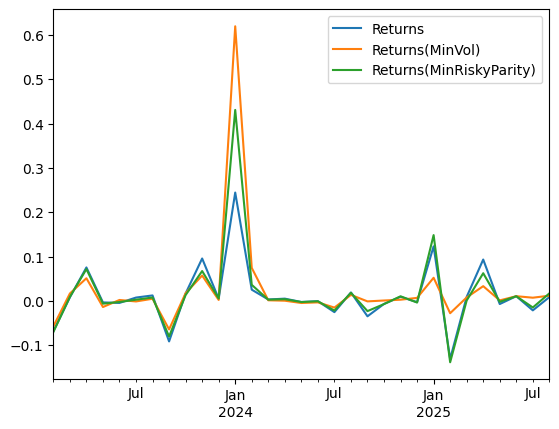

In [ ]:
opt_monthlyend_returns = {"Returns": opt_rets, "Returns(MinVol)": opt_vol_rets, "Returns(MinRiskyParity)": opt_risky_rets}
df_opt_monthlyend_returns = pd.DataFrame(opt_monthlyend_returns, index=months_index)

df_opt_monthlyend_returns.plot()

In [ ]:
(df_opt_monthlyend_returns + 1).prod() - 1

,0
Returns,0.372209
Returns(MinVol),0.941600
Returns(MinRiskyParity),0.559617


In [ ]:
months_index[10]

Timestamp('2023-12-31 00:00:00')

In [ ]:
monthly_returns.index[34]

Timestamp('2023-12-31 00:00:00')

In [ ]:
last_date = monthly_returns.index[34]
print(last_date)

# Slice historical returns up to the last date
historical_returns = monthly_returns.loc[:last_date]

# Calculate the covariance matrix for the historical returns
cov_matrix = historical_returns.cov()

# Calculate expected returns by annualizing the historical returns
expected_returns = annualize_rets(historical_returns)

w_risky = min_risk_parity(risk_free_rate, expected_returns, cov_matrix, bound)
w_vol = min_volatility(risk_free_rate, expected_returns, cov_matrix, bound)
w_msr = msr(risk_free_rate, expected_returns, cov_matrix, bound)

risky_vol = portfolio_vol(w_risky, cov_matrix)
w_risky_vol_max_ret = maximize_return(risky_vol, expected_returns, cov_matrix, bound)

# Plot the Efficient Frontier with the CML
plot_efficient_frontier_with_cml(expected_returns, cov_matrix, bound=bound, riskfree_rate=risk_free_rate, is_risky_parity=True, is_min_vol=True)

2023-12-31 00:00:00


In [ ]:
last_date = monthly_returns.index[34]
last_optimized_weights_df = pd.DataFrame(
    [w_msr],
    index=[last_date],
    columns=monthly_returns.columns
)

# Normalize weights to ensure they sum to 100% for visualization
last_optimized_weights_df = last_optimized_weights_df.div(last_optimized_weights_df.sum(axis=1), axis=0) * 100
plot_optimized_weight_evolution_with_slider_Top10(last_optimized_weights_df)

In [ ]:
last_date = monthly_returns.index[34]
last_optimized_weights_df = pd.DataFrame(
    [w_vol],
    index=[last_date],
    columns=monthly_returns.columns
)

# Normalize weights to ensure they sum to 100% for visualization
last_optimized_weights_df = last_optimized_weights_df.div(last_optimized_weights_df.sum(axis=1), axis=0) * 100
plot_optimized_weight_evolution_with_slider_Top10(last_optimized_weights_df)

### **Bound = (0.01, 0.3)**

In [ ]:
bound =  (0.01, 0.3)

opt_rets = []
opt_vol_rets = []
opt_risky_rets = []
months_index = []
opt_weights_list = []
opt_vol_weights_list = []
opt_risky_weights_list = []

for i_date, date in enumerate(analysis_months):
    # Slice the returns data up to the current date
    historical_returns = monthly_returns.loc[:date]

    # Calculate the covariance matrix for the historical returns
    cov_matrix = historical_returns.cov()

    # Calculate expected returns by annualizing the historical returns
    expected_returns = annualize_rets(historical_returns)

    # Calculate optimized weights (minize risk_parity)
    w_vol = min_volatility(risk_free_rate, expected_returns, cov_matrix, bound)
    w_msr = msr(risk_free_rate, expected_returns, cov_matrix, bound)

    w_risky = min_risk_parity(risk_free_rate, expected_returns, cov_matrix, bound)
    vol_risky_parity = portfolio_vol(w_risky, cov_matrix)
    w_risky_parity_max_ret = maximize_return(vol_risky_parity, expected_returns, cov_matrix, bound)

    if i_date + 1 == len(analysis_months):
        break
    next_date = analysis_months[i_date+1]
    if next_date in monthly_returns.index:
        opt_ret = portfolio_return(w_msr, monthly_returns.loc[next_date])
        opt_vol_ret = portfolio_return(w_vol, monthly_returns.loc[next_date])
        opt_risky_ret = portfolio_return(w_risky_parity_max_ret, monthly_returns.loc[next_date])

        opt_rets.append(opt_ret)
        opt_vol_rets.append(opt_vol_ret)
        opt_risky_rets.append(opt_risky_ret)

        opt_weights_list.append(w_msr)
        opt_vol_weights_list.append(w_vol)
        opt_risky_weights_list.append(w_risky_parity_max_ret)

        months_index.append(next_date)

<Axes: >

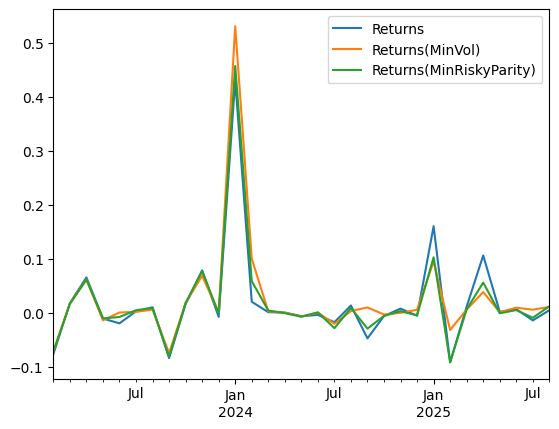

In [ ]:
opt_monthlyend_returns = {"Returns": opt_rets, "Returns(MinVol)": opt_vol_rets, "Returns(MinRiskyParity)": opt_risky_rets}
df_opt_monthlyend_returns = pd.DataFrame(opt_monthlyend_returns, index=months_index)

df_opt_monthlyend_returns.plot()

In [ ]:
(df_opt_monthlyend_returns + 1).prod() - 1

,0
Returns,0.624429
Returns(MinVol),0.957096
Returns(MinRiskyParity),0.604081


In [ ]:
# Plot the Efficient Frontier with the CML
plot_efficient_frontier_with_cml(expected_returns, cov_matrix, bound=bound, riskfree_rate=risk_free_rate, is_risky_parity=True, is_min_vol=True)

In [ ]:
last_date = monthly_returns.index[34]
last_optimized_weights_df = pd.DataFrame(
    [w_msr],
    index=[last_date],
    columns=monthly_returns.columns
)

# Normalize weights to ensure they sum to 100% for visualization
last_optimized_weights_df = last_optimized_weights_df.div(last_optimized_weights_df.sum(axis=1), axis=0) * 100
plot_optimized_weight_evolution_with_slider_Top10(last_optimized_weights_df)

In [ ]:
last_date = monthly_returns.index[34]
last_optimized_weights_df = pd.DataFrame(
    [w_vol],
    index=[last_date],
    columns=monthly_returns.columns
)

# Normalize weights to ensure they sum to 100% for visualization
last_optimized_weights_df = last_optimized_weights_df.div(last_optimized_weights_df.sum(axis=1), axis=0) * 100
plot_optimized_weight_evolution_with_slider_Top10(last_optimized_weights_df)

### **compare to the index ETF SPY**

In [ ]:
str(analysis_months[-1])

'2025-08-31 00:00:00'

In [ ]:
df_spy = yf.download('SPY', start='2023-01-31', end='2025-08-31', progress=False, auto_adjust = False)

df_spy.columns = df_spy.columns.get_level_values(1)

df_spy.reset_index(inplace=True)
df_spy['Ticker Symbol'] = ticker

df_spy.columns = ['Date', 'Adj Close', 'Close', 'High', 'Low', 'Open', 'Volume', 'Ticker Symbol']

In [ ]:
(df_spy['Adj Close'].iloc[-1] - df_spy['Adj Close'].iloc[0]) / df_spy['Adj Close'].iloc[0] * 100

np.float64(64.1448311092837)

from the optimization, the two-years return is around 64% which is more or less close to the max sharpe ratio and min risky partity. But the min volalitity has a larger return.

## **Break out trading**

Instead of managing the protfolio component or using the technical indicator directly, another trend trading stragery using the break through is popular among traders.

By defining roles for capturing the break through, trades can be made. Profit could be made by setting serie of sell roles.

We would define our roles as following:

Buying role:


1.   price just breaks through its nearest resistance level
2.   price is still above that resistance level after two hours

Selling role:


1.   price is below the entry price by a value of ***R***
2.   when price is within a range of ±***R***, hold the trade until 3 weeks ***or*** the price drop below 10-day sma
3.   when the price is higher than 1 ***R***,
hole until price drop below 10-day sma

Since we are playing with hourly data and yfinance only provide 2-year hourly data, the period of interest would be from 2024-01-01 till now.

### **Resistance / Supporting levels extraction**

To trading with the break out, the extraction of the resistance / supporting level plays an important character before making the trading.

We first automatical extract the levels with peak findings and swing lookback. Then, we can manually adjust the levels for increasing the performance.

In [ ]:
from dataclasses import dataclass
import yfinance as yf
from typing import Dict, List, Optional, Tuple
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from scipy.signal import find_peaks
from datetime import timedelta

In [ ]:
def atr(df , n = 14):
    h, l, c = df['High'], df['Low'], df['Close']
    tr = np.maximum(h - l, np.maximum((h - c.shift()).abs(), (l - c.shift()).abs()))
    return tr.rolling(n, min_periods=1).mean()

def _merge_levels(levels, price_tol):
    if not levels :
        return []

    levels = sorted(levels, key=lambda x: (x[1], x[0]))
    merged = []
    cur_times = [levels[0][0]]
    cur_price = levels[0][1]
    cur_kind = levels[0][2]

    touches = 1

    for t, p, k in levels[1:]:
        if (abs(p - cur_price) <= price_tol) and (k == cur_kind):
            # merge by weighted average (equal weights here)
            cur_price = (cur_price * touches + p) / (touches + 1)
            touches += 1
            cur_times.append(t)
        else:
            merged.append((cur_times, cur_price, cur_kind, touches))
            cur_times = [t]
            cur_price = p
            cur_kind = k
            touches = 1

    merged.append((cur_times, cur_price, cur_kind, touches))
    return merged

def _nearest_level(levels, price, kind):
    lv = [x for x in levels if x[2] == kind]
    if not lv:
        return None
    idx = int(np.argmin([abs(x[1] - price) for x in lv]))
    return lv[idx]

def estimate_sr_levels(
    df, swing_lookback = 3,
    prominence_frac = 0.005,
    atr_window = 14,
    atr_merge_mult = 1.0):

    close = df['Close']
    high = df['High']
    low = df['Low']

    prom = max(1e-6, prominence_frac * float(close.iloc[-1]))

    peaks, _ = find_peaks(high.values, distance=swing_lookback, prominence=prom)
    troughs, _ = find_peaks((-low).values, distance=swing_lookback, prominence=prom)

    levels_raw: List[Tuple[pd.Timestamp, float, str]] = []
    for i in peaks:
        levels_raw.append((df.index[i], float(high.iloc[i]), 'resistance'))
    for i in troughs:
        levels_raw.append((df.index[i], float(low.iloc[i]), 'support'))

    avg_atr = float(atr(df, atr_window).mean())
    price_tol = max(1e-6, atr_merge_mult * avg_atr)
    merged = _merge_levels(levels_raw, price_tol=price_tol)
    return merged

In [ ]:
@dataclass
class BreakoutParams:
    atr_window: int = 14
    volume_ma: int = 20
    volume_mult: float = 1.2       # volume confirmation: vol > volume_mult * MA(volume)
    breakout_buffer: float = 0.000 # e.g. 0.001 = need 0.1% beyond resistance
    rr_takeprofit: float = 2.0     # take profit at 2R
    atr_stop_mult: float = 1.0     # add ATR to widen stop (optional; 0 to disable)
    require_retest: bool = False   # if True: wait retest of broken resistance as support

In [ ]:
symbol = "DELL"
df_daily = yf.download(symbol, start="2024-01-01", auto_adjust=True)
df_hourly = yf.download(symbol, start="2024-01-01", auto_adjust=True, interval='1h')

df_daily.columns = [col[0] for col in df_daily.columns]
df_daily.dropna(inplace=True)

df_hourly.columns = [col[0] for col in df_hourly.columns]
df_hourly.dropna(inplace=True)

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


In [ ]:
levels = estimate_sr_levels(
    df_daily,
    swing_lookback=1,        # tighter picks more swings
    prominence_frac=0.015,   # ~0.3% prominence
    atr_window=14,
    atr_merge_mult=1       # merge levels within ~1 ATR
)

Text(0, 0.5, 'Price')

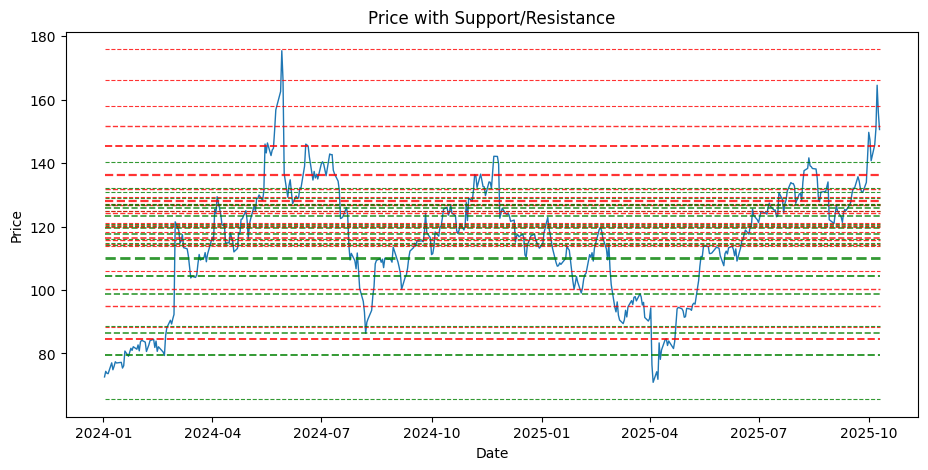

In [ ]:
max_levels = 70
lv_sorted = sorted(levels, key=lambda x: x[3], reverse=True)[:max_levels]

fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(df_daily.index, df_daily['Close'], linewidth=1.0)
for _, price, kind, touches in lv_sorted:
    color = 'g' if kind == 'support' else 'r'
    ax.hlines(price, xmin=df_daily.index[0], xmax=df_daily.index[-1], linestyles='dashed',
              linewidth=min(2, 0.6 + 0.2 * touches), colors=color, alpha=0.8)
ax.set_title("Price with Support/Resistance")
ax.set_xlabel("Date")
ax.set_ylabel("Price")

In [ ]:
sort_levels = sorted(levels, key=lambda x: (x[1]))
avg_atr = float(atr(df_daily, 14).mean())

n_lv = len(sort_levels)
while(True):
    n_merge = 0
    for i in range(n_lv):
        for j in range(i + 1, n_lv):
            if (i >= len(sort_levels) or j >= len(sort_levels)):
                continue

            pi = sort_levels[i][1]
            pj = sort_levels[j][1]

            if abs(pi - pj) < avg_atr * 1.3:
                mdates = sort_levels[i][0] + sort_levels[j][0]
                mprice = (pi * len(sort_levels[i][0]) + pj * len(sort_levels[j][0])) / len(mdates)
                mtorch = sort_levels[i][3] + sort_levels[j][3]
                sort_levels[i] = (mdates, mprice, 'merged', mtorch)
                sort_levels.pop(j)
                n_merge += 1
    if n_merge == 0:
        break

Text(0, 0.5, 'Price')

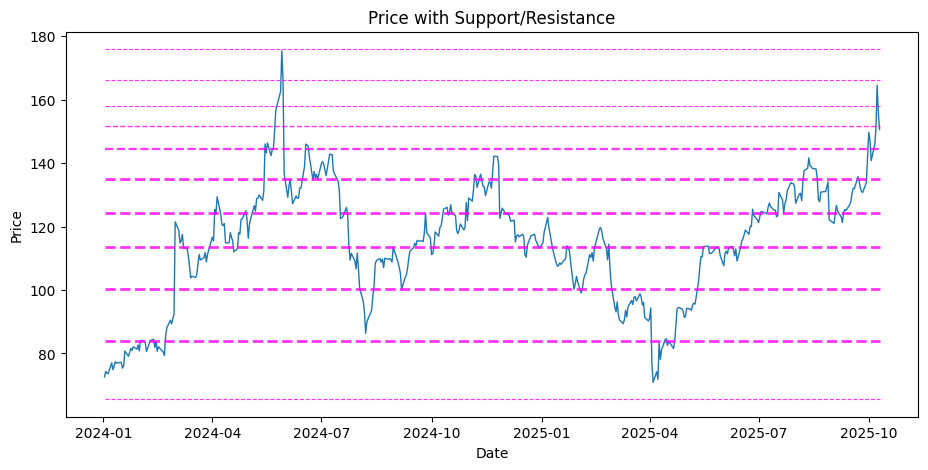

In [ ]:
max_levels = 20

fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(df_daily.index, df_daily['Close'], linewidth=1.0)
for _, price, kind, touches in sort_levels:
    color = 'magenta'
    ax.hlines(price, xmin=df_daily.index[0], xmax=df_daily.index[-1], linestyles='dashed',
              linewidth=min(2, 0.6 + 0.2 * touches), colors=color, alpha=0.8)
ax.set_title("Price with Support/Resistance")
ax.set_xlabel("Date")
ax.set_ylabel("Price")

### **break out trading**

In [ ]:
def is_setup_forming(close: float, level: float, proximity_pct: float) -> bool:
    lower = level * (1 - proximity_pct)
    return (close < level) and (close >= lower)

def ema(series: pd.Series, span: int) -> pd.Series:
    return series.ewm(span=span, adjust=False, min_periods=span).mean()

def compute_daily_indicators(hourly: pd.DataFrame,
                             ema_fast_days: int,
                             ema_slow_days: int,
                             atr_days: int,
                             adr_window: int) -> pd.DataFrame:
    daily = pd.DataFrame({
        'Open': hourly['Open'].resample('1D').first(),
        'High': hourly['High'].resample('1D').max(),
        'Low': hourly['Low'].resample('1D').min(),
        'Close': hourly['Close'].resample('1D').last(),
        'Volume': hourly['Volume'].resample('1D').sum(),
    }).dropna()

    daily['EMA_F'] = ema(daily['Close'], ema_fast_days)
    daily['EMA_S'] = ema(daily['Close'], ema_slow_days)
    daily['ATR']   = atr(daily, n=atr_days)
    daily['Range'] = daily['High'] - daily['Low']
    daily[f'ADR'] = daily['Range'].rolling(window=adr_window).mean()

    hourly_ind = pd.DataFrame(index=hourly.index)
    hourly_ind[['EMA_F','EMA_S','ATR', 'ADR']] = daily[['EMA_F','EMA_S','ATR', 'ADR']].reindex(hourly.index, method='ffill')
    return hourly_ind

In [ ]:
@dataclass
class Trade:
    entry_time: pd.Timestamp
    entry_price: float
    level: float
    shares: int
    R: float
    ADR: float
    exit_time: Optional[pd.Timestamp] = None
    exit_price: Optional[float] = None
    reason: Optional[str] = None

@dataclass
class StrategyParams:
    proximity_pct: float = 0.01
    confirm_hours: int = 2
    ema_fast_days: int = 10
    ema_slow_days: int = 20
    atr_days: int = 14
    adr_window: int = 14
    position_size: int = 100         # fixed number of shares per entry


In [ ]:
def generate_trades(hourly: pd.DataFrame,
                    levels: List[float],
                    VarR: float,
                    params: StrategyParams) -> List[Trade]:
    hourly = hourly.sort_index().copy()
    ind = compute_daily_indicators(hourly,
                                   params.ema_fast_days,
                                   params.ema_slow_days,
                                   params.atr_days,
                                   params.adr_window)
    df = hourly.join(ind, how='left')

    # Track one active position per level
    lvls = sorted(levels)
    avg_level_gap = np.mean(np.diff(lvls))

    active_by_level: Dict[float, Optional[Trade]] = {float(L): None for L in lvls}
    trades: List[Trade] = []

    idx = df.index
    n = len(df)
    max_pos = 0
    n_pos_list = []
    for i in range(1, n):
        now = idx[i]
        row_now = df.iloc[i]
        row_prev = df.iloc[i-1]

        ema_fast_now = row_now['EMA_F']
        ema_slow_now = row_now['EMA_S']
        if np.isnan(ema_fast_now) or np.isnan(ema_slow_now):
            # not enough data yet for EMAs
            continue

        # -------- EXIT management (check exits on all active positions first) --------
        for L, pos in list(active_by_level.items()):
            if pos is None:
                continue

            n_pos += 1

            entry_px = pos.entry_price
            # R = pos.R if (pos.R is not None and pos.R > 0) else _compute_R(entry_px, L, row_now)
            R = pos.R
            stop_px   = entry_px - R
            target_px = entry_px + 2.0 * R
            chk_px = entry_px + R
            ADR = pos.ADR

            close_now = float(row_now['Close'])
            exit_reason = None
            # Profit first or stop first? In practice, either can trigger; prioritize TP if both happen to be true.
            if close_now >= chk_px:
                if close_now < float(ema_fast_now - ADR):
                    exit_reason = 'take_profit'
            elif (stop_px < close_now < chk_px and
                (now > pos.entry_time + timedelta(weeks=3) or close_now < float(ema_fast_now - ADR))):
                exit_reason = '>3 weeks_or_below_EMA10'
            elif (close_now <= stop_px):  # below R-stop OR below EMA20
                exit_reason = 'stop_R'

            if exit_reason is not None:
                pos.exit_time = now
                pos.exit_price = close_now
                pos.reason = exit_reason
                trades.append(pos)
                active_by_level[L] = None  # free the level for future re-entries

        # -------- ENTRY detection (only when uptrend) --------
        # Only search new entries if current bar is uptrend
        if float(ema_fast_now) <= float(ema_slow_now):
            continue

        close_prev = float(row_prev['Close'])
        close_now  = float(row_now['Close'])

        for L in active_by_level.keys():
            # Skip if already holding this level
            if active_by_level[L] is not None:
                continue

            crossed_now = (close_prev <= L) and (close_now > L)
            if not crossed_now:
                continue

            # Confirmation exactly confirm_hours bars later
            k = i + params.confirm_hours
            if k >= n:
                # not enough future bars to confirm
                continue

            row_conf = df.iloc[k]
            ema_fast_conf = row_conf['EMA_F']
            ema_slow_conf = row_conf['EMA_S']
            if np.isnan(ema_fast_conf) or np.isnan(ema_slow_conf):
                continue

            # Must still be in uptrend at confirmation and close still above level
            if (float(ema_fast_conf) > float(ema_slow_conf)) and (float(row_conf['Close']) > L):
                entry_ts = idx[k]
                entry_px = float(row_conf['Close'])
                # R_val = avg_level_gap / 2 + row_now['ADR'] * 0.5
                if VarR is None:
                    R_val = avg_level_gap / 2 + row_now['ADR'] * 0.5
                else:
                    R_val = min(abs(entry_px * VarR), avg_level_gap / 2 + row_now['ADR'] * 0.5)

                trade = Trade(
                    entry_time=entry_ts,
                    entry_price=entry_px,
                    level=float(L),
                    shares=int(params.position_size),
                    R=R_val,
                    ADR=row_now['ADR'],
                )

                active_by_level[L] = trade  # mark active
        n_pos = 0
        for L in active_by_level.keys():
            if active_by_level[L] is not None:
                n_pos += 1
        n_pos_list.append(n_pos)
        max_pos = max(n_pos, max_pos)
    avg_pos = sum(n_pos_list) / len(n_pos_list)
    for pos in active_by_level.values():
        if pos is not None and pos not in trades:
            trades.append(pos)

    return trades, max_pos, avg_pos

In [ ]:
params = StrategyParams(
    proximity_pct=0.01,
    confirm_hours=2,
    ema_fast_days=10,
    ema_slow_days=20,
    atr_days=14,
    adr_window = 14,
    position_size = 100
)

In [ ]:
confidence_level = 0.95
returns = df_daily['Close'].pct_change().dropna()
Var95 = np.percentile(returns, (1 - confidence_level) * 100)
trades, max_pos, avg_pos = generate_trades(df_hourly, [x[1] for x in sort_levels], Var95, params)
max_pos, avg_pos

(6, 1.1395713538944068)

In [ ]:
profit = 0
cost  = 0
last_price = df_daily['Close'].iloc[-1]
for trade in trades:
    cost += trade.entry_price
    if trade.exit_price is None:
        profit += last_price - trade.entry_price
    else:
        profit += trade.exit_price - trade.entry_price
print(f"Total Profit: {profit}")

Total Profit: -192.3178939819336


In [ ]:
profit_loss_cnt = {'profit': 0, 'loss': 0}
for i, trade in enumerate(trades):
    if trade.reason is None:
        if (trade.entry_price >= last_price):
            profit_loss_cnt['loss'] += 1
            PorL = "Loss  "
        else:
            profit_loss_cnt['profit'] += 1
            PorL = "Profit"
        print("trade {:2} - entry date: {}\tentry: {:3.8f}\texit: {:3.8f}\t{}\tADR: {:3.8f}\tR: {:3.8f}\treason: {}".format(i, trade.entry_time, trade.entry_price, last_price, PorL, trade.ADR, trade.R, 'hold until end'))

    else:
        if (trade.entry_price >= trade.exit_price):
            profit_loss_cnt['loss'] += 1
            PorL = "Loss  "
        else:
            profit_loss_cnt['profit'] += 1
            PorL = "Profit"
        print("trade {:2} - entry date: {}\tentry: {:3.8f}\texit: {:3.8f}\t{}\tADR: {:3.8f}\tR: {:3.8f}\treason: {}".format(i, trade.entry_time, trade.entry_price, trade.exit_price, PorL, trade.ADR, trade.R, trade.reason))

print(profit_loss_cnt)

trade  0 - entry date: 2024-01-30 16:30:00+00:00	entry: 85.01999664	exit: 81.48000336	Loss  	ADR: 2.05097035	R: 4.08162470	reason: >3 weeks_or_below_EMA10
trade  1 - entry date: 2024-03-04 15:30:00+00:00	entry: 124.41000366	exit: 117.37500000	Loss  	ADR: 3.57737132	R: 5.97265308	reason: stop_R
trade  2 - entry date: 2024-03-01 16:30:00+00:00	entry: 121.22000122	exit: 115.12999725	Loss  	ADR: 3.57737132	R: 5.81950801	reason: stop_R
trade  3 - entry date: 2024-03-01 16:30:00+00:00	entry: 121.22000122	exit: 115.12999725	Loss  	ADR: 3.57737132	R: 5.81950801	reason: stop_R
trade  4 - entry date: 2024-02-22 16:30:00+00:00	entry: 88.58999634	exit: 108.01499939	Profit	ADR: 2.13571385	R: 4.25301261	reason: take_profit
trade  5 - entry date: 2024-03-21 15:30:00+00:00	entry: 114.97000122	exit: 119.89499664	Profit	ADR: 4.76362882	R: 5.51945914	reason: >3 weeks_or_below_EMA10
trade  6 - entry date: 2024-04-03 16:30:00+00:00	entry: 127.16999817	exit: 119.89499664	Loss  	ADR: 4.54235731	R: 6.10515440

### **Testing**

In [ ]:
# sel_tickers = df_pass['ticker'].iloc[-10:].tolist()
sel_tickers = ['DELL', 'ORCL', 'STX', 'WDC', 'ANET', 'META', 'AVGO', 'NVDA', 'PLTR', 'APP', 'SPY']
sel_tickers

['DELL',
 'ORCL',
 'STX',
 'WDC',
 'ANET',
 'META',
 'AVGO',
 'NVDA',
 'PLTR',
 'APP',
 'SPY']

In [ ]:
break_out_results = {}
confidence_level = 0.95
for ticker in sel_tickers:
    df_daily = yf.download(ticker, start="2024-01-01", auto_adjust=True)
    df_hourly = yf.download(ticker, start="2024-01-01", auto_adjust=True, interval='1h')

    df_daily.columns = [col[0] for col in df_daily.columns]
    df_daily.dropna(inplace=True)

    df_hourly.columns = [col[0] for col in df_hourly.columns]
    df_hourly.dropna(inplace=True)

    levels = estimate_sr_levels(
        df_daily,
        swing_lookback=1,        # tighter picks more swings
        prominence_frac=0.015,   # ~0.3% prominence
        atr_window=14,
        atr_merge_mult=1       # merge levels within ~1 ATR
    )

    sort_levels = sorted(levels, key=lambda x: (x[1]))
    avg_atr = float(atr(df_daily, 14).mean())

    n_lv = len(sort_levels)
    while(True):
        n_merge = 0
        for i in range(n_lv):
            for j in range(i + 1, n_lv):
                if (i >= len(sort_levels) or j >= len(sort_levels)):
                    continue

                pi = sort_levels[i][1]
                pj = sort_levels[j][1]

                if abs(pi - pj) < avg_atr * 1.3:
                    mdates = sort_levels[i][0] + sort_levels[j][0]
                    mprice = (pi * len(sort_levels[i][0]) + pj * len(sort_levels[j][0])) / len(mdates)
                    mtorch = sort_levels[i][3] + sort_levels[j][3]
                    sort_levels[i] = (mdates, mprice, 'merged', mtorch)
                    sort_levels.pop(j)
                    n_merge += 1
        if n_merge == 0:
            break

    returns = df_daily['Close'].pct_change().dropna()
    Var95 = np.percentile(returns, (1 - confidence_level) * 100)
    trades, max_pos, avg_pos = generate_trades(df_hourly, [x[1] for x in sort_levels], Var95, params)

    profit = 0
    last_price = df_daily['Close'].iloc[-1]
    profit_loss_cnt = {'profit': 0, 'loss': 0}
    for trade in trades:
        if trade.exit_price is None:
            profit += last_price - trade.entry_price
            if (trade.entry_price >= last_price):
                profit_loss_cnt['loss'] += 1
            else:
                profit_loss_cnt['profit'] += 1
        else:
            profit += trade.exit_price - trade.entry_price
            if (trade.entry_price >= trade.exit_price):
                profit_loss_cnt['loss'] += 1
            else:
                profit_loss_cnt['profit'] += 1
    break_out_results[ticker] = {
        "Profit": profit,
        "nProfitTrade": profit_loss_cnt['profit'],
        "nLossTrade": profit_loss_cnt['loss'],
        "winRate": profit_loss_cnt['profit'] / (profit_loss_cnt['profit'] + profit_loss_cnt['loss']),
        "avgPos": avg_pos,
        "Profit_per_AvgPos": profit / avg_pos
    }


[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%********

In [ ]:
df_break_out_result = pd.DataFrame(break_out_results)
df_break_out_result

,DELL,ORCL,STX,WDC,ANET,META,AVGO,NVDA,PLTR,APP,SPY
Profit,-192.317894,266.321381,300.327438,288.217712,11.806770,69.330170,113.335266,128.354057,225.791235,659.451889,142.101898
nProfitTrade,9.000000,15.000000,14.000000,14.000000,12.000000,15.000000,13.000000,14.000000,19.000000,18.000000,14.000000
nLossTrade,32.000000,24.000000,17.000000,11.000000,27.000000,19.000000,22.000000,18.000000,20.000000,24.000000,18.000000
winRate,0.219512,0.384615,0.451613,0.560000,0.307692,0.441176,0.371429,0.437500,0.487179,0.428571,0.437500
avgPos,1.139571,2.225601,1.885757,2.154253,1.333784,1.485064,1.467273,1.761103,2.003070,1.642735,1.712789
Profit_per_AvgPos,-168.763363,119.662692,159.260907,133.790109,8.852083,46.684971,77.242127,72.882782,112.722578,401.435333,82.965201
